# Clase 4 - EPG4002

## Selección de número de clusters y componentes principales en R

Este notebook replica la lógica del notebook en Python, pero usando código R. Se enfatiza el método **Gap Statistic**, ya que en Python no estaba implementado directamente en el material original.

La base utilizada es `iris`, manteniendo la misma estructura del notebook Python: primero se analiza la cantidad de grupos y luego se revisa PCA.

In [1]:
# Librerías necesarias
library(cluster)

# Opcional: fijar semilla para reproducibilidad
set.seed(123)

# 1. Base de datos y estandarización

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
,<dbl>,<dbl>,<dbl>,<dbl>
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2
6,5.4,3.9,1.7,0.4


  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  

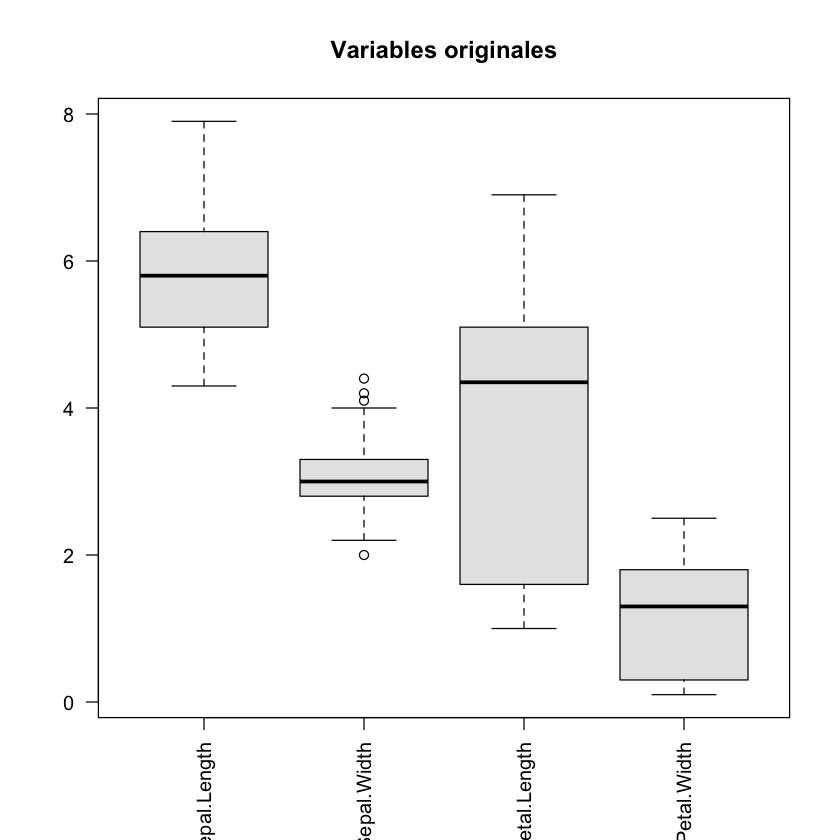

In [2]:
# Base de datos iris
data(iris)

X <- iris[, 1:4]
y <- iris$Species

head(X)
summary(X)

boxplot(X, main = "Variables originales", las = 2, col = "gray90")

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.8976739,1.01560199,-1.335752,-1.311052
2,-1.1392005,-0.13153881,-1.335752,-1.311052
3,-1.3807271,0.32731751,-1.392399,-1.311052
4,-1.5014904,0.09788935,-1.279104,-1.311052
5,-1.0184372,1.24503015,-1.335752,-1.311052
6,-0.5353840,1.93331463,-1.165809,-1.048667


  Sepal.Length       Sepal.Width       Petal.Length      Petal.Width     
 Min.   :-1.86378   Min.   :-2.4258   Min.   :-1.5623   Min.   :-1.4422  
 1st Qu.:-0.89767   1st Qu.:-0.5904   1st Qu.:-1.2225   1st Qu.:-1.1799  
 Median :-0.05233   Median :-0.1315   Median : 0.3354   Median : 0.1321  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.67225   3rd Qu.: 0.5567   3rd Qu.: 0.7602   3rd Qu.: 0.7880  
 Max.   : 2.48370   Max.   : 3.0805   Max.   : 1.7799   Max.   : 1.7064  

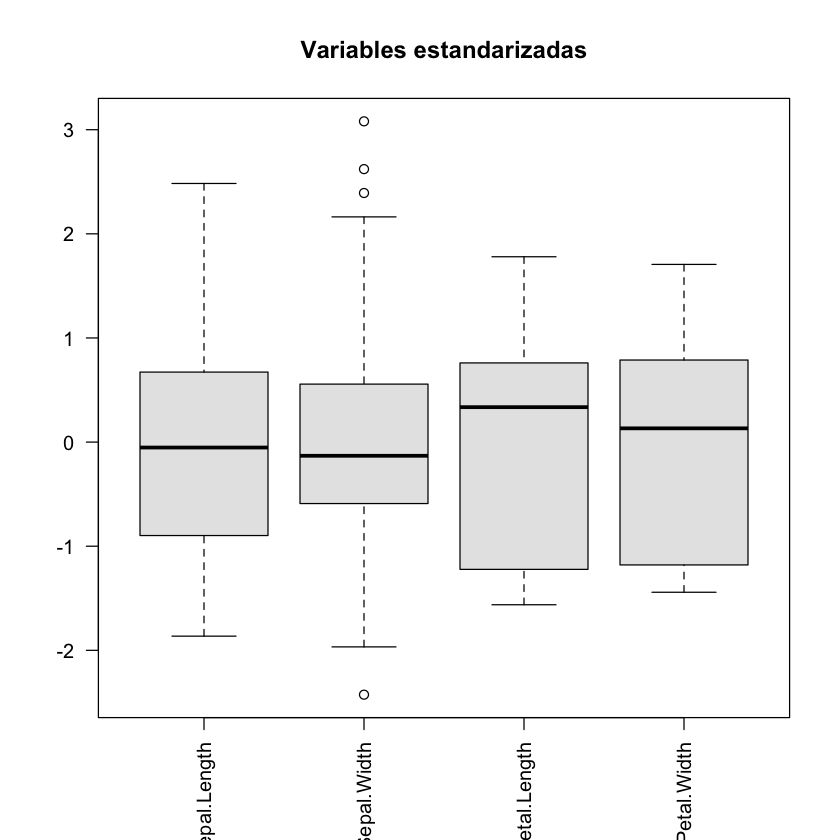

In [3]:
# Estandarización de variables
X_scale <- as.data.frame(scale(X))

head(X_scale)
summary(X_scale)

boxplot(X_scale, main = "Variables estandarizadas", las = 2, col = "gray90")

# 2. Determinación de cantidad de grupos

## 2.1 Método del codo con K-means

El método del codo evalúa cómo disminuye la suma de cuadrados intra-cluster total al aumentar el número de grupos. En R, esta cantidad corresponde a `tot.withinss` en el objeto resultante de `kmeans`.

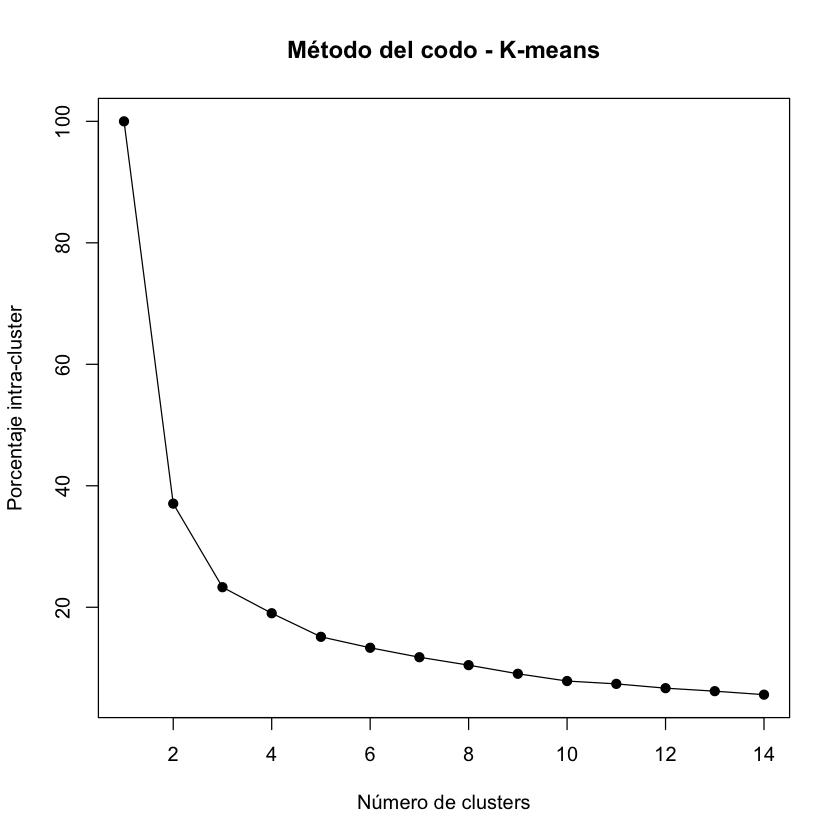

In [4]:
Kmax <- 14
W_kmeans <- numeric(Kmax)

for(k in 1:Kmax){
  km <- kmeans(X_scale, centers = k, nstart = 30)
  W_kmeans[k] <- km$tot.withinss
}

plot(1:Kmax, W_kmeans / W_kmeans[1] * 100,
     type = "o", pch = 19,
     xlab = "Número de clusters",
     ylab = "Porcentaje intra-cluster",
     main = "Método del codo - K-means")

## 2.2 Dendrograma con enlace Ward

Para variables numéricas estandarizadas se puede utilizar distancia euclidiana y enlace Ward. En R, la versión recomendada para Ward con distancia euclidiana es `ward.D2`.

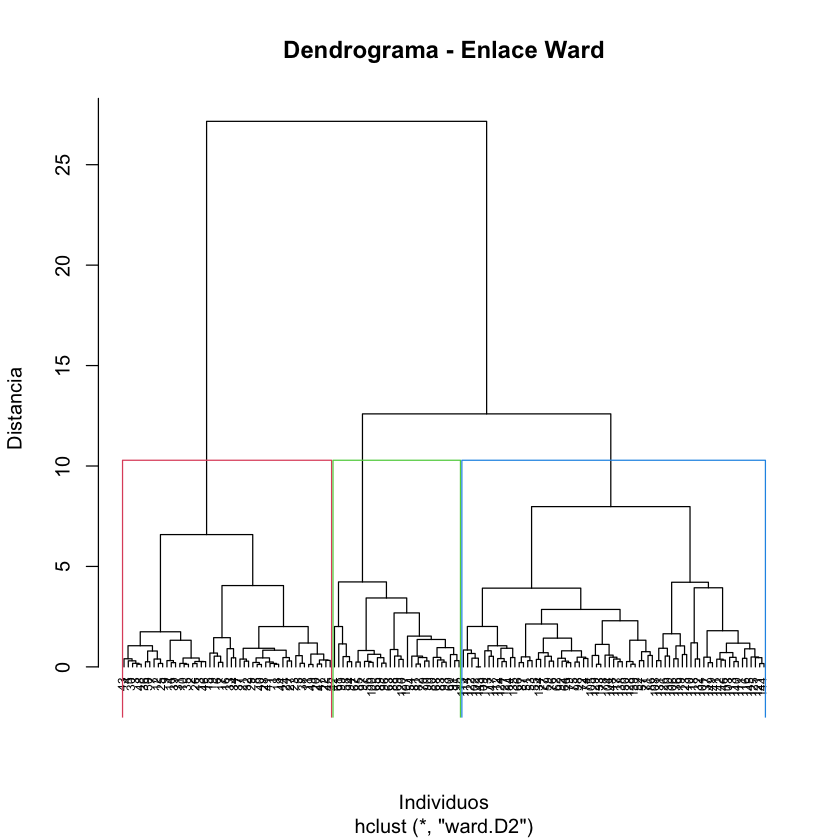

In [5]:
D_euc <- dist(X_scale, method = "euclidean")

hc_ward <- hclust(D_euc, method = "ward.D2")

plot(hc_ward, hang = -1, cex = 0.6,
     main = "Dendrograma - Enlace Ward",
     xlab = "Individuos",
     ylab = "Distancia")
rect.hclust(hc_ward, k = 3, border = 2:4)

## 2.3 Suma intra-cluster para métodos jerárquicos

La siguiente función reproduce la lógica de los scripts en R: para cada valor de `k`, corta el árbol y calcula una medida de dispersión intra-cluster usando la matriz de distancias.

In [6]:
Within <- function(hc, d, Kmax, tipo = "all") {
  within <- numeric(Kmax)
  D <- as.matrix(d)
  
  for(k in 1:Kmax){
    wit <- 0
    grupos <- cutree(hc, k = k)
    
    for(j in 1:k){
      aux <- grupos == j
      if(sum(aux) > 1){
        if(tipo == "mean"){
          wit <- wit + mean(D[aux, aux]) / 2
        } else {
          wit <- wit + sum(D[aux, aux]) / 2
        }
      }
    }
    within[k] <- wit
  }
  return(within)
}

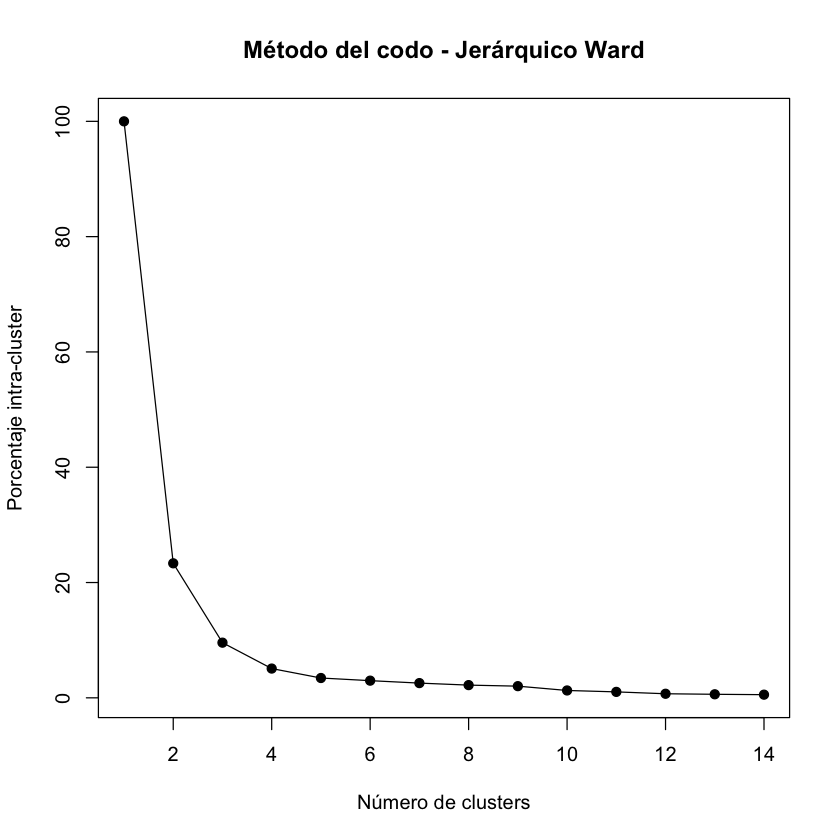

In [7]:
Kmax <- 14
W_hc <- Within(hc_ward, D_euc^2, Kmax)

plot(1:Kmax, W_hc / W_hc[1] * 100,
     type = "o", pch = 19,
     xlab = "Número de clusters",
     ylab = "Porcentaje intra-cluster",
     main = "Método del codo - Jerárquico Ward")

## 2.4 Criterio de Calinski-Harabasz

Este criterio compara dispersión entre grupos y dispersión dentro de grupos. Valores más altos sugieren una mejor partición.

[1] 14

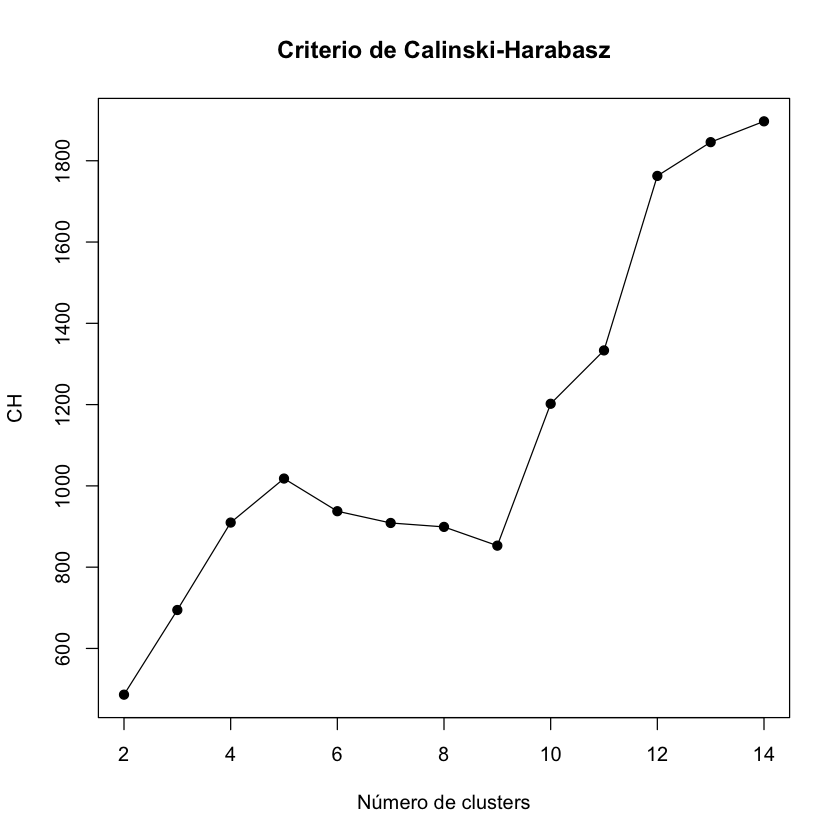

In [8]:
CH <- function(n, WK){
  Kmax <- length(WK)
  T <- WK[1]
  BK <- T - WK
  K <- 2:Kmax
  
  num <- BK[-1] / (K - 1)
  den <- WK[-1] / (n - K)
  CH <- num / den
  
  return(CH)
}

CH_hc <- CH(n = nrow(X_scale), WK = W_hc)

plot(2:Kmax, CH_hc,
     type = "o", pch = 19,
     xlab = "Número de clusters",
     ylab = "CH",
     main = "Criterio de Calinski-Harabasz")

which.max(CH_hc) + 1

## 2.5 Criterio de Hartigan

Una regla habitual es escoger el primer valor de `k` para el cual el estadístico de Hartigan deja de ser suficientemente grande. En algunos textos se usa el umbral 10.

[1] NA

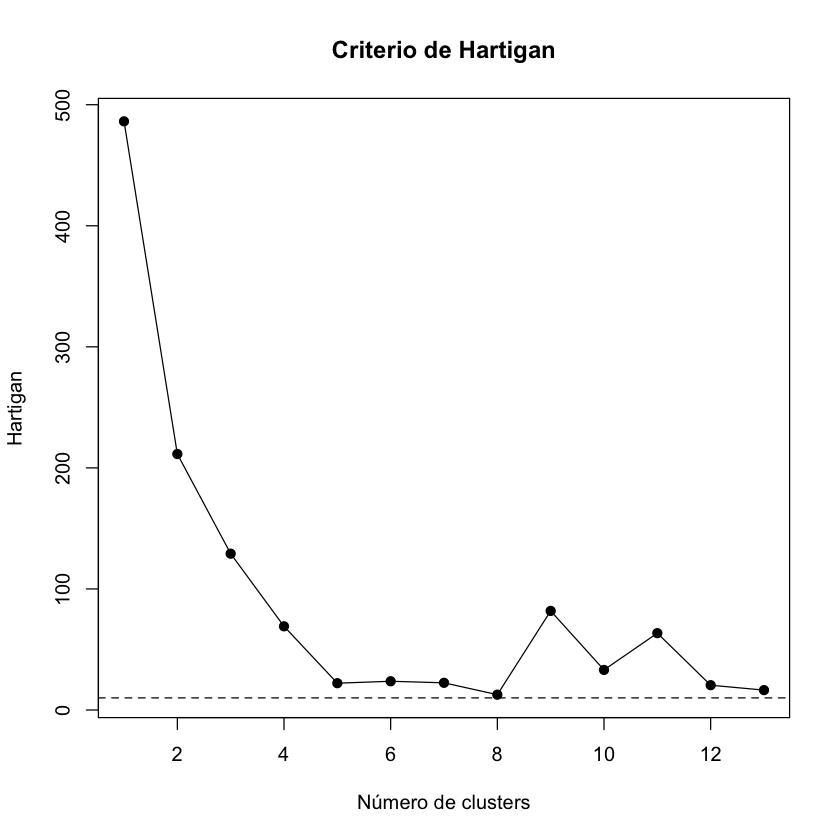

In [9]:
Hartigan <- function(n, WK){
  Kmax <- length(WK)
  K <- 1:(Kmax - 1)
  H <- (WK[-Kmax] / WK[-1] - 1) * (n - K - 1)
  return(H)
}

H_hc <- Hartigan(n = nrow(X_scale), WK = W_hc)

plot(1:(Kmax - 1), H_hc,
     type = "o", pch = 19,
     xlab = "Número de clusters",
     ylab = "Hartigan",
     main = "Criterio de Hartigan")
abline(h = 10, lty = 2)

# Primer k donde H(k) < 10
which(H_hc < 10)[1]

# 3. Gap Statistic

El **Gap Statistic** compara la dispersión intra-cluster observada con la dispersión esperada bajo una distribución de referencia sin estructura de grupos.

La idea es:

\[
Gap(k) = E^*\{\log(W_k^*)\} - \log(W_k),
\]

por lo que valores grandes indican que la partición observada mejora de forma importante respecto de lo esperable bajo ausencia de clusters.

En R, el cálculo está implementado en `clusGap()` del paquete `cluster`. La función requiere una rutina que, para cada `k`, devuelva una lista con el vector `cluster`.

In [10]:
# Función auxiliar para K-means
kmeansCut <- function(x, k, ...){
  km <- kmeans(x, centers = k, nstart = 30, ...)
  return(list(cluster = km$cluster))
}

# Función auxiliar para clustering jerárquico
hclusCut <- function(x, k, diss = "euclidean", method = "ward.D2", ...){
  hc <- hclust(dist(x, method = diss), method = method, ...)
  grupos <- cutree(hc, k = k)
  return(list(cluster = grupos))
}

## 3.1 Gap Statistic para K-means

Clustering Gap statistic ["clusGap"] from call:
clusGap(x = X_scale, FUNcluster = kmeansCut, K.max = 10, B = 200, d.power = 2)
B=200 simulated reference sets, k = 1..10; spaceH0="scaledPCA"
 --> Number of clusters (method 'firstSEmax', SE.factor=1): 3
          logW   E.logW       gap     SE.sim
 [1,] 5.697093 6.066003 0.3689094 0.05045854
 [2,] 4.704469 5.545083 0.8406133 0.05627935
 [3,] 4.240523 5.148383 0.9078593 0.04806202
 [4,] 4.037171 4.810171 0.7730004 0.04586409
 [5,] 3.808903 4.632734 0.8238303 0.04328940
 [6,] 3.682176 4.484534 0.8023577 0.03994858
 [7,] 3.558024 4.358049 0.8000246 0.03741788
 [8,] 3.437366 4.248464 0.8110979 0.03784753
 [9,] 3.294758 4.154940 0.8601822 0.03722936
[10,] 3.153096 4.074660 0.9215638 0.03782373


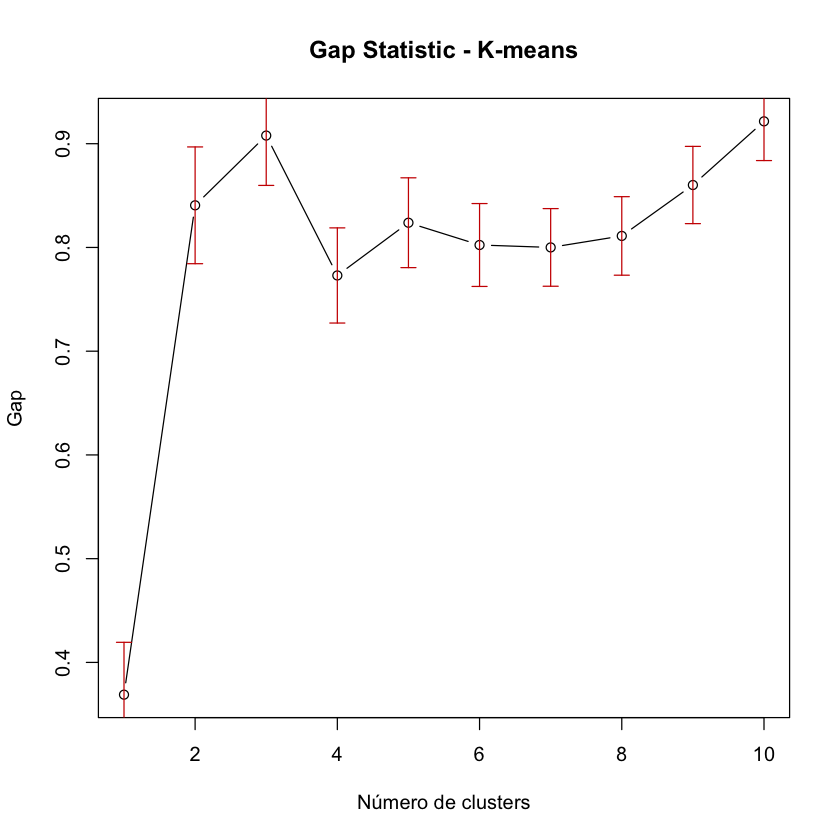

In [11]:
set.seed(123)

gap_kmeans <- clusGap(
  x = X_scale,
  FUNcluster = kmeansCut,
  K.max = 10,
  B = 200,
  d.power = 2
)

print(gap_kmeans)

plot(gap_kmeans,
     main = "Gap Statistic - K-means",
     xlab = "Número de clusters",
     ylab = "Gap")

In [12]:
# Distintas reglas de selección implementadas en R
k_gap_kmeans <- c(
  Tibs2001SEmax = maxSE(gap_kmeans$Tab[, "gap"], gap_kmeans$Tab[, "SE.sim"], method = "Tibs2001SEmax"),
  firstSEmax    = maxSE(gap_kmeans$Tab[, "gap"], gap_kmeans$Tab[, "SE.sim"], method = "firstSEmax"),
  globalmax     = maxSE(gap_kmeans$Tab[, "gap"], gap_kmeans$Tab[, "SE.sim"], method = "globalmax")
)

k_gap_kmeans

Tibs2001SEmax    firstSEmax     globalmax 
            3             3            10

## 3.2 Gap Statistic para clustering jerárquico Ward

Esta es una diferencia importante respecto del notebook Python: en R se puede calcular Gap Statistic usando una función de clustering jerárquico definida por el usuario.

Clustering Gap statistic ["clusGap"] from call:
clusGap(x = X_scale, FUNcluster = hclusCut, K.max = 10, B = 200, d.power = 2, diss = "euclidean", method = "ward.D2")
B=200 simulated reference sets, k = 1..10; spaceH0="scaledPCA"
 --> Number of clusters (method 'firstSEmax', SE.factor=1): 3
          logW   E.logW       gap     SE.sim
 [1,] 5.697093 6.067637 0.3705435 0.05430401
 [2,] 4.732667 5.608481 0.8758138 0.06161182
 [3,] 4.303279 5.243752 0.9404731 0.06336940
 [4,] 4.060954 4.933377 0.8724226 0.06534590
 [5,] 3.854111 4.739569 0.8854578 0.06015839
 [6,] 3.754547 4.582723 0.8281756 0.05629651
 [7,] 3.644867 4.450035 0.8051671 0.05473363
 [8,] 3.531687 4.338284 0.8065978 0.05238256
 [9,] 3.411327 4.242430 0.8311032 0.04965890
[10,] 3.275813 4.158018 0.8822050 0.04678483


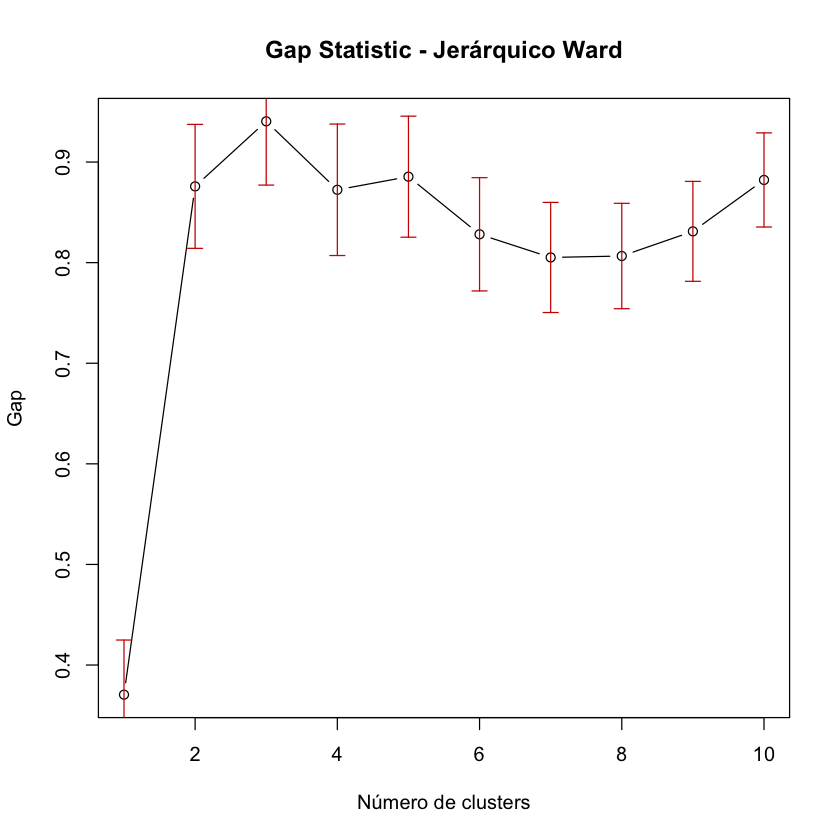

In [13]:
set.seed(123)

gap_hc_ward <- clusGap(
  x = X_scale,
  FUNcluster = hclusCut,
  K.max = 10,
  B = 200,
  diss = "euclidean",
  method = "ward.D2",
  d.power = 2
)

print(gap_hc_ward)

plot(gap_hc_ward,
     main = "Gap Statistic - Jerárquico Ward",
     xlab = "Número de clusters",
     ylab = "Gap")

In [14]:
k_gap_hc <- c(
  Tibs2001SEmax = maxSE(gap_hc_ward$Tab[, "gap"], gap_hc_ward$Tab[, "SE.sim"], method = "Tibs2001SEmax"),
  firstSEmax    = maxSE(gap_hc_ward$Tab[, "gap"], gap_hc_ward$Tab[, "SE.sim"], method = "firstSEmax"),
  globalmax     = maxSE(gap_hc_ward$Tab[, "gap"], gap_hc_ward$Tab[, "SE.sim"], method = "globalmax")
)

k_gap_hc

Tibs2001SEmax    firstSEmax     globalmax 
            3             3             3

## 3.3 Comparación de métodos de selección de `k`

La tabla siguiente resume los valores sugeridos por distintos criterios. La interpretación no debe ser mecánica: estos métodos orientan la decisión, pero se deben contrastar con el dendrograma y con la interpretación del problema.

In [15]:
resumen_k <- data.frame(
  Metodo = c("Codo jerárquico", "Calinski-Harabasz", "Hartigan",
             "Gap K-means - Tibs2001SEmax", "Gap K-means - globalmax",
             "Gap HC Ward - Tibs2001SEmax", "Gap HC Ward - globalmax"),
  K_sugerido = c(NA, which.max(CH_hc) + 1, which(H_hc < 10)[1],
                 k_gap_kmeans["Tibs2001SEmax"], k_gap_kmeans["globalmax"],
                 k_gap_hc["Tibs2001SEmax"], k_gap_hc["globalmax"])
)

resumen_k

Metodo,K_sugerido
<chr>,<dbl>
Codo jerárquico,NA
Calinski-Harabasz,14
Hartigan,NA
Gap K-means - Tibs2001SEmax,3
Gap K-means - globalmax,10
Gap HC Ward - Tibs2001SEmax,3
Gap HC Ward - globalmax,3


# 4. Silhouette

Esta sección replica el notebook Python y los scripts R, pero puede dejarse como material complementario si aún no se ha discutido formalmente el índice de silueta.

[1] 2

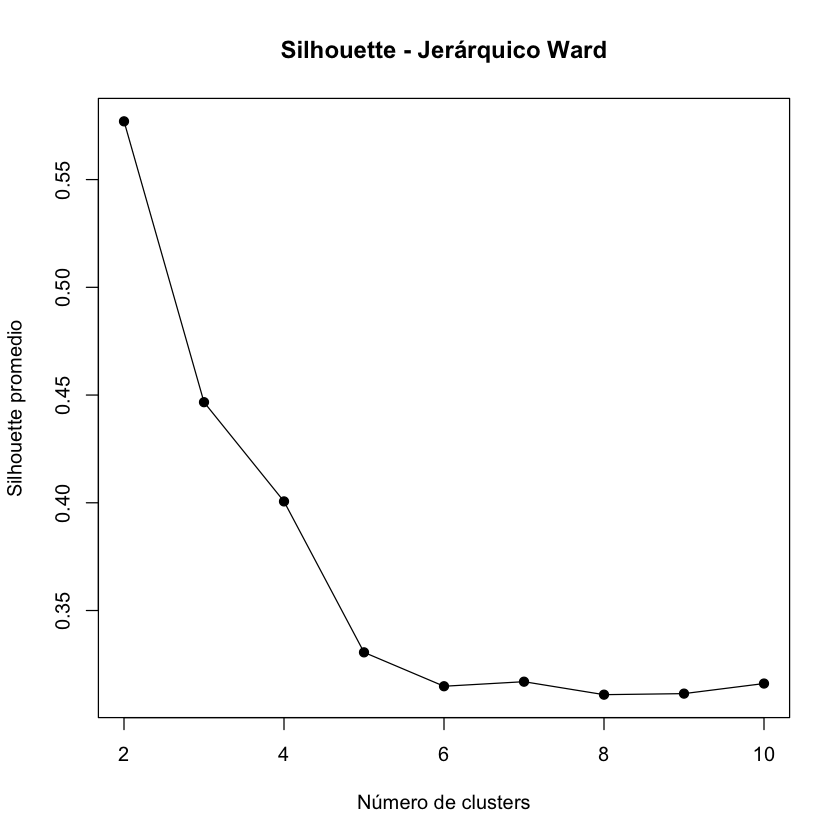

In [16]:
sil_hclust <- function(hc, d, Kmax){
  aux <- rep(NA, Kmax)
  for(k in 2:Kmax){
    grupos <- cutree(hc, k = k)
    aux[k] <- mean(silhouette(grupos, d)[, 3])
  }
  return(aux)
}

sil_hc <- sil_hclust(hc_ward, D_euc, Kmax = 10)

plot(2:10, sil_hc[2:10],
     type = "o", pch = 19,
     xlab = "Número de clusters",
     ylab = "Silhouette promedio",
     main = "Silhouette - Jerárquico Ward")

which.max(sil_hc)

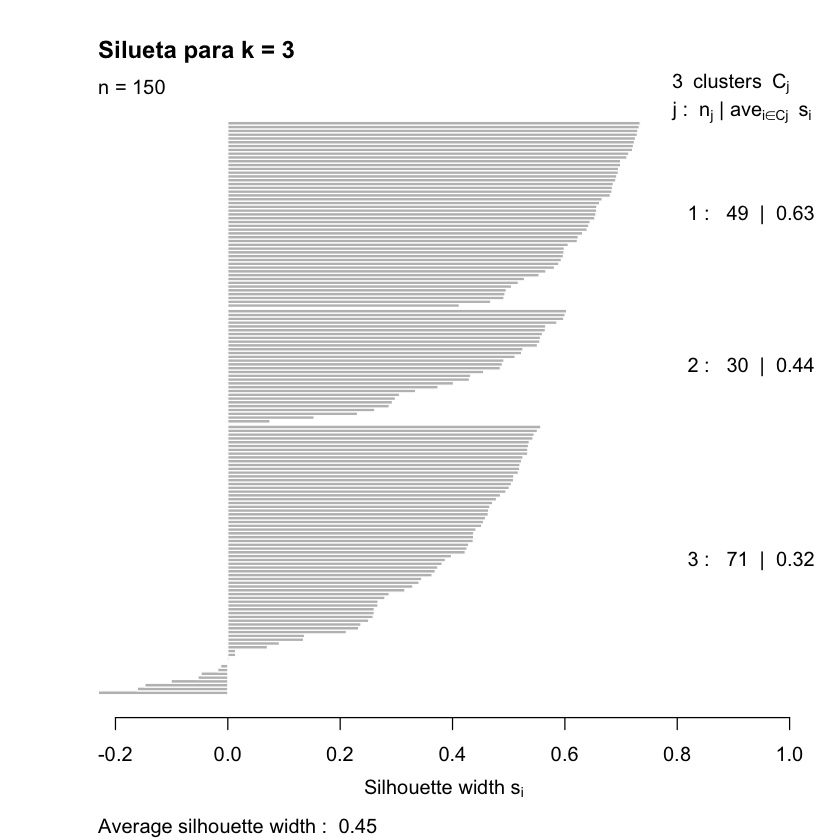

In [17]:
# Gráfico de silueta para k = 3
grupos_hc3 <- cutree(hc_ward, k = 3)
plot(silhouette(grupos_hc3, D_euc), main = "Silueta para k = 3")

# 5. Componentes principales

## 5.1 Cálculo manual mediante matriz de covarianza y correlación

In [18]:
# Matriz de covarianza y correlación de los datos estandarizados
cov_X <- cov(X_scale)
cor_X <- cor(X_scale)

cov_X
cor_X

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.0000000,-0.1175698,0.8717538,0.8179411
Sepal.Width,-0.1175698,1.0000000,-0.4284401,-0.3661259
Petal.Length,0.8717538,-0.4284401,1.0000000,0.9628654
Petal.Width,0.8179411,-0.3661259,0.9628654,1.0000000


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.0000000,-0.1175698,0.8717538,0.8179411
Sepal.Width,-0.1175698,1.0000000,-0.4284401,-0.3661259
Petal.Length,0.8717538,-0.4284401,1.0000000,0.9628654
Petal.Width,0.8179411,-0.3661259,0.9628654,1.0000000


In [19]:
# Autovalores y autovectores
eig_cov <- eigen(cov_X)
eig_cor <- eigen(cor_X)

eig_cov$values
eig_cov$vectors

eig_cor$values
eig_cor$vectors

[1] 2.91849782 0.91403047 0.14675688 0.02071484

0.5210659,-0.37741762,0.7195664,0.2612863
-0.2693474,-0.92329566,-0.2443818,-0.1235096
0.5804131,-0.02449161,-0.1421264,-0.8014492
0.5648565,-0.06694199,-0.6342727,0.5235971


[1] 2.91849782 0.91403047 0.14675688 0.02071484

0.5210659,-0.37741762,0.7195664,0.2612863
-0.2693474,-0.92329566,-0.2443818,-0.1235096
0.5804131,-0.02449161,-0.1421264,-0.8014492
0.5648565,-0.06694199,-0.6342727,0.5235971


In [20]:
# Varianza explicada usando los autovalores
var_exp <- eig_cov$values / sum(eig_cov$values)
var_acum <- cumsum(var_exp)

data.frame(
  Componente = paste0("PC", 1:length(var_exp)),
  Varianza = round(var_exp, 4),
  Varianza_acumulada = round(var_acum, 4)
)

Componente,Varianza,Varianza_acumulada
<chr>,<dbl>,<dbl>
PC1,0.7296,0.7296
PC2,0.2285,0.9581
PC3,0.0367,0.9948
PC4,0.0052,1.0000


## 5.2 PCA usando `prcomp`

In [21]:
pca <- prcomp(X, center = TRUE, scale. = TRUE)

summary(pca)
pca$rotation

Importance of components:
                          PC1    PC2     PC3     PC4
Standard deviation     1.7084 0.9560 0.38309 0.14393
Proportion of Variance 0.7296 0.2285 0.03669 0.00518
Cumulative Proportion  0.7296 0.9581 0.99482 1.00000

,PC1,PC2,PC3,PC4
Sepal.Length,0.5210659,-0.37741762,0.7195664,0.2612863
Sepal.Width,-0.2693474,-0.92329566,-0.2443818,-0.1235096
Petal.Length,0.5804131,-0.02449161,-0.1421264,-0.8014492
Petal.Width,0.5648565,-0.06694199,-0.6342727,0.5235971


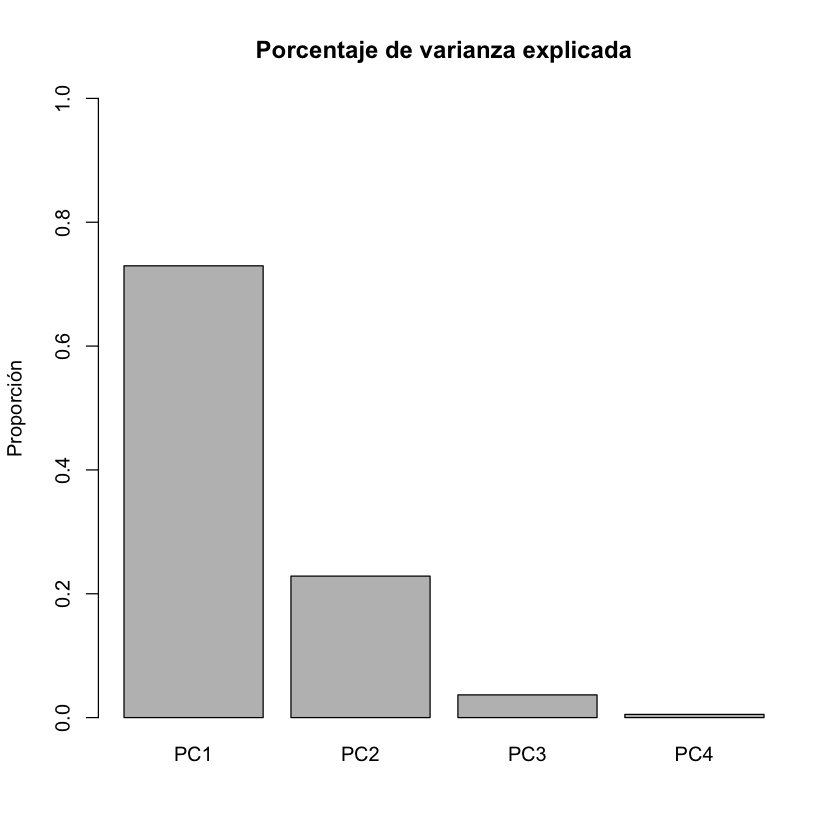

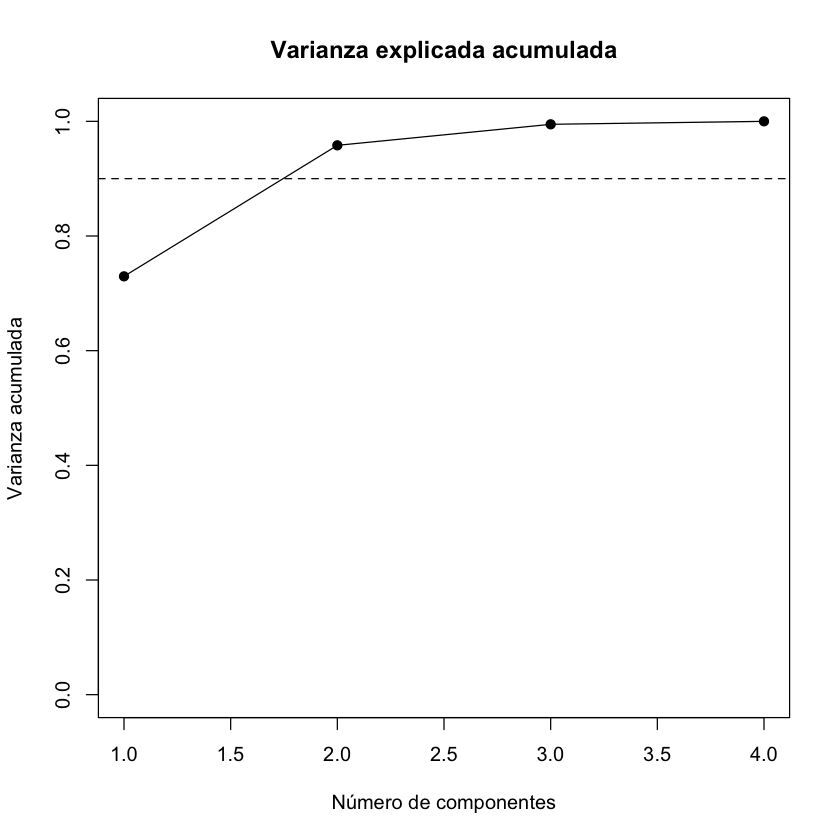

In [22]:
# Gráfico de varianza explicada
var_pca <- pca$sdev^2 / sum(pca$sdev^2)

barplot(var_pca,
        names.arg = paste0("PC", 1:length(var_pca)),
        ylim = c(0, 1),
        main = "Porcentaje de varianza explicada",
        ylab = "Proporción")

# Varianza acumulada
plot(cumsum(var_pca),
     type = "o", pch = 19, ylim = c(0, 1),
     xlab = "Número de componentes",
     ylab = "Varianza acumulada",
     main = "Varianza explicada acumulada")
abline(h = 0.90, lty = 2)

In [23]:
# Proyecciones de las observaciones
proyecciones <- as.data.frame(pca$x)
head(proyecciones)

,PC1,PC2,PC3,PC4
,<dbl>,<dbl>,<dbl>,<dbl>
1,-2.257141,-0.4784238,0.12727962,0.024087508
2,-2.074013,0.6718827,0.23382552,0.102662845
3,-2.356335,0.3407664,-0.04405390,0.028282305
4,-2.291707,0.5953999,-0.09098530,-0.065735340
5,-2.381863,-0.6446757,-0.01568565,-0.035802870
6,-2.068701,-1.4842053,-0.02687825,0.006586116


# 6. Clustering y visualización en componentes principales

In [27]:
# K-means con k = 3 sobre los datos estandarizados
set.seed(123)
km3 <- kmeans(X_scale, centers = 3, nstart = 30)

table(Clase_real = y, Cluster = km3$cluster)

            Cluster
Clase_real    1  2  3
  setosa     50  0  0
  versicolor  0 39 11
  virginica   0 14 36

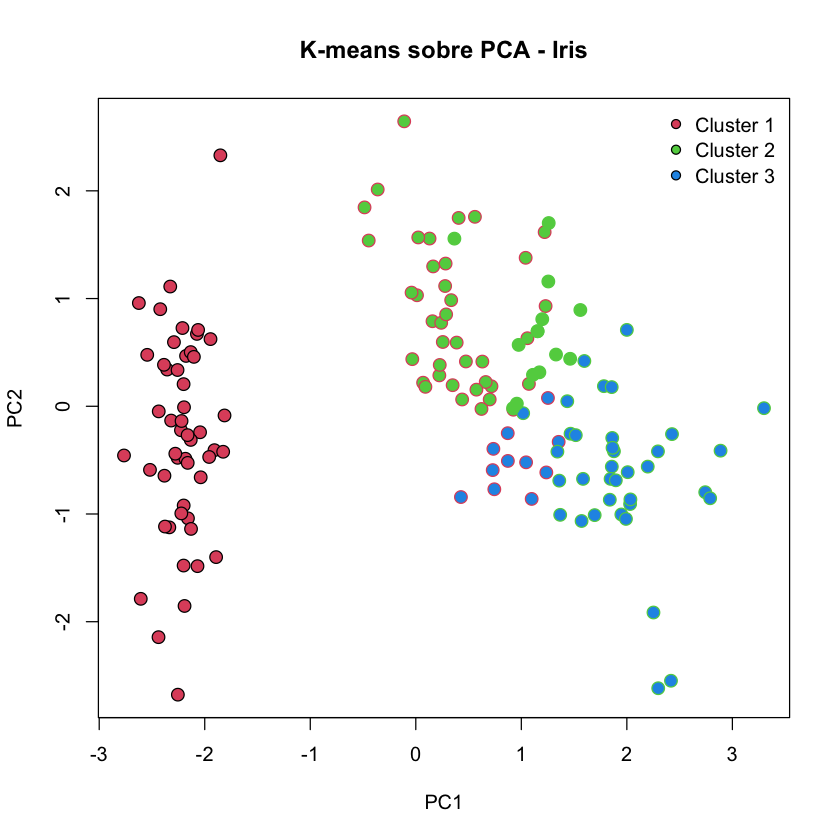

In [25]:
# Visualización usando las dos primeras componentes principales
plot(proyecciones$PC1, proyecciones$PC2,
     pch = 21,
     bg = km3$cluster + 1,
     col = as.numeric(y),
     cex = 1.4,
     xlab = "PC1",
     ylab = "PC2",
     main = "K-means sobre PCA - Iris")
legend("topright",
       legend = paste("Cluster", 1:3),
       pt.bg = 2:4, pch = 21, bty = "n")

            Cluster
Clase_real    1  2  3
  setosa     50  0  0
  versicolor  0 11 39
  virginica   0 36 14

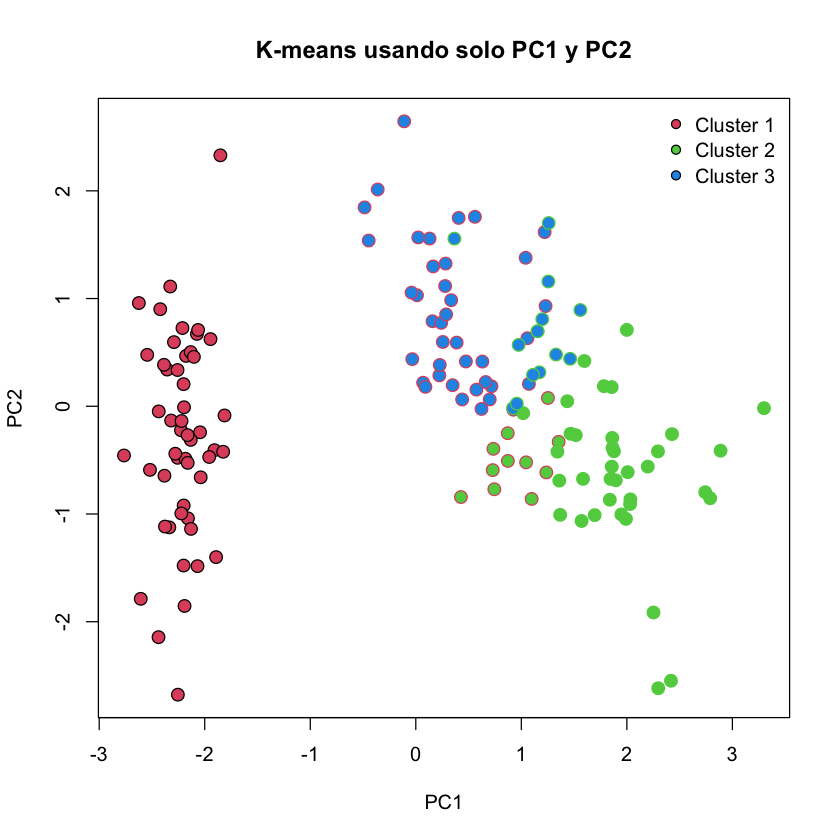

In [26]:
# K-means usando solo las dos primeras componentes principales
set.seed(123)
km_pca <- kmeans(proyecciones[, c("PC1", "PC2")], centers = 3, nstart = 30)

table(Clase_real = y, Cluster = km_pca$cluster)

plot(proyecciones$PC1, proyecciones$PC2,
     pch = 21,
     bg = km_pca$cluster + 1,
     col = as.numeric(y),
     cex = 1.4,
     xlab = "PC1",
     ylab = "PC2",
     main = "K-means usando solo PC1 y PC2")
legend("topright",
       legend = paste("Cluster", 1:3),
       pt.bg = 2:4, pch = 21, bty = "n")

# Comentario final

Este notebook reproduce los elementos centrales del análisis en Python, pero agrega una implementación explícita del **Gap Statistic** en R mediante `clusGap()`. La ventaja de esta formulación es que permite evaluar tanto K-means como clustering jerárquico usando funciones auxiliares que devuelven una partición para cada valor de `k`.

En términos docentes, el flujo recomendado es:

1. observar la necesidad de estandarizar,
2. evaluar candidatos para `k` con codo, CH y Hartigan,
3. introducir Gap Statistic como comparación con una referencia sin estructura,
4. usar PCA para visualizar la partición final.